[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/heitorramos/icd/blob/main/exemplos/10-tcl-inferencia/notebook-colab.ipynb)


In [ ]:
# Preparação automática para execução no Google Colab.
# Fora do Colab, esta célula não altera o diretório de trabalho.
try:
    import google.colab  # type: ignore
except ImportError:
    pass
else:
    import os
    import subprocess
    from pathlib import Path

    repository = Path("/content/icd")
    if not repository.exists():
        subprocess.run([
            "git", "clone", "--depth", "1",
            "https://github.com/heitorramos/icd.git", str(repository)
        ], check=True)
    os.chdir(repository / "exemplos/10-tcl-inferencia")
    print("Material preparado em:", Path.cwd())


# TCL, intervalos e testes com dados Olist

Notebook das Aulas 10 e 11

# Objetivos

Este notebook usa pedidos reais do e-commerce brasileiro Olist para
conectar distribuições amostrais, Teorema Central do Limite, intervalos
de confiança e testes de hipóteses.

Ao final, você deve conseguir:

- simular a distribuição amostral de uma média ou proporção;
- comparar erro padrão empírico e teórico;
- construir e interpretar intervalos de confiança;
- simular a cobertura de um procedimento;
- formular hipóteses e calcular uma estatística de teste;
- estimar um p-valor por aproximação e por simulação;
- investigar erros tipo I e poder estatístico.

## Como estudar este capítulo

Este material conecta variação amostral e decisão estatística. O Teorema
Central do Limite descreve por que, sob condições adequadas, a
distribuição de muitas médias amostrais se aproxima de uma Normal. Essa
aproximação permite calcular erros padrão e intervalos sem enumerar
todas as amostras possíveis.

O ponto de partida não é a curva Normal, mas a repetição imaginária do
estudo. Cada nova amostra produz uma média diferente. A distribuição
dessas médias é a distribuição amostral; seu desvio padrão é o erro
padrão. Um intervalo de confiança usa essa variabilidade para construir
um procedimento que cobre o parâmetro em uma proporção conhecida de
repetições.

Na parte de testes, a pergunta muda: verificamos quão incompatível a
estatística observada é com uma hipótese nula. O valor-p não é a
probabilidade de a hipótese ser verdadeira; ele é calculado assumindo a
hipótese nula. Leia as simulações como representações de experimentos
repetidos e não como tentativas de “provar” uma afirmação.

### Duas aulas, um encadeamento

A Aula 10 desenvolve LGN, TCL, erro padrão e intervalos. A Aula 11
utiliza a mesma lógica de distribuição amostral para construir testes,
erros tipo I e poder. O material específico e mais detalhado da Aula 11
complementa este capítulo com uma análise completa da taxa de atrasos.

# 1. Download da base

In [ ]:
import kagglehub

path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
print(path)

# 2. Preparação

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import binom, norm, t

sns.set_theme(style="whitegrid", context="notebook")
rng = np.random.default_rng(20260824)

orders_path = next(Path(path).rglob("olist_orders_dataset.csv"))
orders = pd.read_csv(orders_path)

date_cols = [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]
orders[date_cols] = orders[date_cols].apply(pd.to_datetime)
orders = orders.dropna(subset=date_cols).copy()

orders["delivery_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.total_seconds() / 86400

orders["delay_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

orders["late"] = (orders["delay_days"] > 0).astype(int)
orders[["delivery_days", "delay_days", "late"]].describe()

# 3. População didática

In [ ]:
delivery = orders["delivery_days"].to_numpy()
late = orders["late"].to_numpy()

mu = delivery.mean()
sigma = delivery.std(ddof=0)
p_late = late.mean()

print(f"Pedidos válidos: {len(orders):,}")
print(f"Tempo médio: {mu:.2f} dias")
print(f"Desvio padrão: {sigma:.2f} dias")
print(f"Taxa de atraso: {p_late:.2%}")

> **Interpretação**
>
> A distribuição amostral descreve como a estatística varia entre
> amostras. O TCL aproxima a média por uma Normal quando as condições
> são adequadas; aumentar n reduz o erro padrão, mas não corrige viés de
> seleção ou dependência.

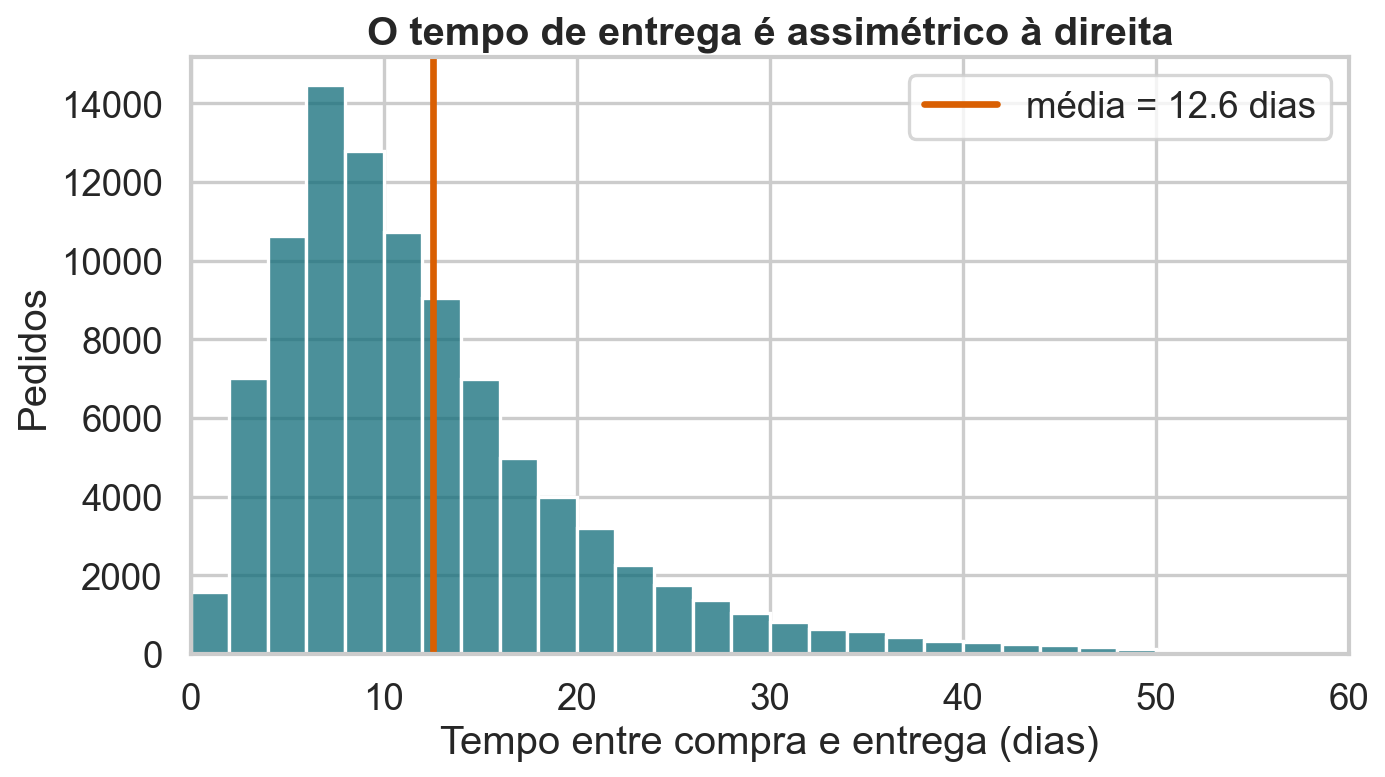

## 3.1 Duas amostras da mesma população

Uma amostra representa apenas uma das muitas seleções que poderiam ter
sido obtidas. Para tornar essa ideia visível, retiramos duas amostras
independentes de 30 pedidos da mesma população didática e usamos
exatamente os mesmos intervalos e escalas nos dois histogramas. Como
agora comparamos densidades, normalizamos os histogramas para que a área
total seja 1. A curva sobreposta é uma estimativa não paramétrica da
função densidade de probabilidade obtida por KDE (*kernel density
estimation*).

In [ ]:
comparison_rng = np.random.default_rng(20260909)
sample_a = comparison_rng.choice(delivery, size=30, replace=False)
sample_b = comparison_rng.choice(delivery, size=30, replace=False)
bins_samples = np.arange(0, 61, 5)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), sharex=True, sharey=True)
for ax, sample, label, color in [
    (axes[0], sample_a, "Amostra A", "#0f6b78"),
    (axes[1], sample_b, "Amostra B", "#d95f02"),
]:
    sns.histplot(
        sample, bins=bins_samples, stat="density", color=color, alpha=.48, ax=ax
    )
    sns.kdeplot(
        sample, color=color, linewidth=3, cut=0, clip=(0, 60),
        label=r"KDE: $\hat f_h(x)$", ax=ax,
    )
    ax.axvline(mu, color="#17324d", linewidth=2, linestyle="--",
               label=f"μ = {mu:.1f}")
    ax.axvline(sample.mean(), color=color, linewidth=3,
               label=f"x̄ = {sample.mean():.1f}")
    ax.set_xlim(0, 60)
    ax.set_xlabel("Tempo de entrega (dias)")
    ax.set_title(f"{label}: n = 30")
    ax.legend()
axes[0].set_ylabel("Densidade")
axes[1].set_ylabel("")
plt.show()

print(f"Média da amostra A: {sample_a.mean():.2f} dias")
print(f"Média da amostra B: {sample_b.mean():.2f} dias")
print(f"Média populacional: {mu:.2f} dias")

> **Interpretação**
>
> Os histogramas e as curvas $\hat f_h(x)$ diferem mesmo com o mesmo
> tamanho amostral e a mesma população de origem. As médias também não
> coincidem entre si nem com $\mu$. Essa diferença não indica erro no
> cálculo: ela representa a variabilidade natural introduzida pela
> seleção aleatória de apenas 30 pedidos. O estimador KDE suaviza o
> histograma, mas também varia de uma amostra para outra e depende da
> largura de banda $h$ usada na suavização.

# 4. Distribuição amostral da média

In [ ]:
def sample_means(values, n, reps=5000):
    return np.array([
        rng.choice(values, size=n, replace=True).mean()
        for _ in range(reps)
    ])

for n in [10, 50, 200]:
    means = sample_means(delivery, n)
    sns.kdeplot(means, label=f"n = {n}")

plt.axvline(mu, color="black", linestyle="--")
plt.xlabel("Média amostral do tempo de entrega")
plt.legend()
plt.show()

Compare o erro padrão empírico com $\sigma/\sqrt{n}$:

In [ ]:
for n in [10, 50, 200, 1000]:
    empirical = sample_means(delivery, n).std(ddof=1)
    theoretical = sigma / np.sqrt(n)
    print(f"n={n:>4}: simulado={empirical:.3f} | teórico={theoretical:.3f}")

> **Interpretação**
>
> As médias amostrais permanecem centradas perto da média populacional,
> enquanto sua dispersão diminui com $n$. A concordância entre simulação
> e $\sigma/\sqrt n$ mostra que o erro padrão descreve a variabilidade
> entre amostras, não a dispersão dos pedidos individuais.

# 5. Padronização

## Condições usuais para aplicar o TCL

Na versão clássica para a média, o TCL parte de observações
independentes e provenientes da mesma distribuição, com média $\mu$ e
variância finita $\sigma^2$. Em aplicações, essas hipóteses precisam ser
conectadas ao modo como os dados foram coletados:

- **Amostragem adequada:** o mecanismo de seleção deve sustentar a
  inferência para a população de interesse. O TCL não corrige viés de
  seleção.
- **Independência:** medidas repetidas, séries temporais, redes e
  amostras por conglomerados podem exigir métodos que representem a
  dependência.
- **Variância finita:** caudas tão pesadas que produzam variância
  infinita ficam fora do TCL clássico.
- **Tamanho suficiente:** não existe uma regra universal $n\geq30$.
  Quanto maiores a assimetria e o peso das caudas, maior tende a ser a
  amostra necessária para uma aproximação Normal satisfatória.

Em uma população finita de tamanho $N$, a amostragem sem reposição
introduz dependência. Quando $n/N<10\%$, ela costuma ser pequena. Para
frações amostrais maiores, o erro padrão da média incorpora a correção

$$
\operatorname{SE}(\bar X)=\frac{\sigma}{\sqrt n}
\sqrt{\frac{N-n}{N-1}}.
$$

Aqui, $N$ é o tamanho da população e $n$ é o tamanho da amostra.

## Uma amostra pequena pode esconder a cauda

Considere uma população lognormal, fortemente assimétrica à direita.
Mesmo assim, uma amostra pequena pode não conter nenhum valor raro da
cauda e produzir um histograma que parece aproximadamente simétrico. Uma
segunda amostra, agora com 100 observações, ajuda a visualizar como o
aumento de $n$ torna mais provável capturar valores da cauda.

In [ ]:
sigma_log = 1.15
x = np.linspace(0.03, 25, 1200)
population_pdf = (
    np.exp(-(np.log(x) ** 2) / (2 * sigma_log**2))
    / (x * sigma_log * np.sqrt(2 * np.pi))
)

rng_shape = np.random.default_rng(20260228)
small_sample = rng_shape.lognormal(mean=0, sigma=sigma_log, size=20)
larger_sample = rng_shape.lognormal(mean=0, sigma=sigma_log, size=100)

fig, axes = plt.subplots(1, 3, figsize=(14.2, 4.8))
axes[0].plot(x, population_pdf, color="#0f6b78", linewidth=3)
axes[0].fill_between(x, population_pdf, color="#0f6b78", alpha=.22)
axes[0].set(xlim=(0, 25), title="População com cauda pesada",
            xlabel="Valor de X", ylabel="Densidade")

sns.histplot(small_sample, bins=np.linspace(0, 3, 7), stat="density",
             color="#d95f02", alpha=.62, ax=axes[1])
sns.kdeplot(small_sample, color="#d95f02", linewidth=3,
            cut=0, clip=(0, 3), ax=axes[1])
axes[1].set(xlim=(0, 3), title="Uma amostra de n = 20",
            xlabel="Valor observado de X", ylabel="Densidade")

sns.histplot(larger_sample, bins=np.linspace(0, 15, 11), stat="density",
             color="#6a4c93", alpha=.58, ax=axes[2])
sns.kdeplot(larger_sample, color="#6a4c93", linewidth=3,
            cut=0, clip=(0, 15), ax=axes[2])
axes[2].set(xlim=(0, 15), title="Outra amostra: n = 100",
            xlabel="Valor observado de X", ylabel="Densidade")
plt.show()

print(f"Maior valor observado na amostra: {small_sample.max():.2f}")
print(f"Maior valor observado com n=100: {larger_sample.max():.2f}")
print(f"Percentil 99% da população: {np.exp(sigma_log * 2.326):.2f}")

> **Interpretação**
>
> Na amostra de tamanho 20, o maior valor ficou muito abaixo do
> percentil 99% da população e o histograma não revelou a cauda longa.
> Na amostra de tamanho 100, aparecem valores bem maiores e a assimetria
> fica clara. O segundo resultado é mais provável com uma amostra maior,
> mas não é garantido em uma realização específica. Por isso, a ausência
> visual de assimetria em uma amostra pequena não justifica
> automaticamente a aproximação Normal da média.

In [ ]:
n = 50
means = sample_means(delivery, n)
z = (means - mu) / (sigma / np.sqrt(n))

sns.histplot(z, bins=35, stat="density")
x = np.linspace(-4, 4, 400)
plt.plot(x, norm.pdf(x), color="darkorange", linewidth=3)
plt.xlabel("Médias padronizadas")
plt.show()

> **Interpretação**
>
> Depois de subtrair $\mu$ e dividir pelo erro padrão, a distribuição
> fica aproximadamente centrada em zero e com escala unitária. A
> comparação com a curva Normal avalia visualmente a aproximação
> fornecida pelo TCL.

# 6. Um intervalo de confiança

Uma analogia útil vem do **GPS**. O pino no mapa funciona como uma
estimativa pontual: a média amostral $\bar X$ fornece uma localização
específica para a média populacional $\mu$. Essa estimativa é
informativa, mas sozinha não mostra quanto poderia variar se
repetíssemos a amostragem.

O círculo de precisão do GPS funciona como uma região de confiança. Em
uma dimensão, seu análogo é o intervalo $[L,U]$, que reúne valores
plausíveis para $\mu$ de acordo com a variabilidade amostral. Aumentar a
região eleva a frequência com que o procedimento cobre o parâmetro, mas
diminui a precisão da estimativa.

> **A analogia e a interpretação frequentista**
>
> Imagine repetir a coleta e obter um novo pino e uma nova região a cada
> amostra. Um procedimento de 95% produz intervalos que contêm o
> parâmetro fixo em aproximadamente 95% dessas repetições. Depois que
> observamos uma amostra e calculamos seu intervalo, ele contém ou não
> contém $\mu$.

O TCL fornece, sob as condições discutidas anteriormente, a aproximação

$$
-1{,}96<\frac{\bar X-\mu}{\sigma/\sqrt n}<1{,}96.
$$

Aqui, $\bar X$ é a média amostral, $\mu$ é a média populacional,
$\sigma$ é o desvio padrão populacional e $n$ é o tamanho da amostra. O
termo $\sigma/\sqrt n$ é o erro padrão de $\bar X$.

Para obter uma faixa para $\mu$, primeiro multiplicamos toda a
desigualdade por $\sigma/\sqrt n$. Esse termo é positivo, portanto as
desigualdades mantêm o sentido:

$$
-1{,}96\frac{\sigma}{\sqrt n}<\bar X-\mu
<1{,}96\frac{\sigma}{\sqrt n}.
$$

Em seguida, subtraímos $\bar X$ dos três termos:

$$
-\bar X-1{,}96\frac{\sigma}{\sqrt n}<-\mu<
-\bar X+1{,}96\frac{\sigma}{\sqrt n}.
$$

Ao multiplicar por $-1$, precisamos inverter o sentido das
desigualdades:

$$
\bar X+1{,}96\frac{\sigma}{\sqrt n}>\mu>
\bar X-1{,}96\frac{\sigma}{\sqrt n}.
$$

Reordenando do menor para o maior, isolamos $\mu$:

$$
\boxed{\bar X-1{,}96\frac{\sigma}{\sqrt n}<\mu<
\bar X+1{,}96\frac{\sigma}{\sqrt n}}.
$$

Na prática, $\sigma$ costuma ser desconhecido. O exemplo abaixo
substitui o erro padrão populacional por sua estimativa $s/\sqrt n$, em
que $s$ é o desvio padrão calculado na amostra.

In [ ]:
sample = rng.choice(delivery, size=100, replace=False)
x_bar = sample.mean()
s = sample.std(ddof=1)
se = s / np.sqrt(len(sample))
lower = x_bar - 1.96 * se
upper = x_bar + 1.96 * se

print(f"Média amostral: {x_bar:.2f}")
print(f"Erro padrão: {se:.2f}")
print(f"IC 95%: [{lower:.2f}, {upper:.2f}]")

> **Interpretação**
>
> O intervalo combina a estimativa observada com sua incerteza. Os 95%
> referem-se ao desempenho do procedimento em repetições: não significam
> que exista 95% de probabilidade de o parâmetro fixo estar neste
> intervalo já calculado.

# 7. Cobertura

In [ ]:
def confidence_interval(values, n=100, z_star=1.96):
    sample = rng.choice(values, size=n, replace=True)
    mean = sample.mean()
    se = sample.std(ddof=1) / np.sqrt(n)
    return mean - z_star * se, mean + z_star * se

intervals = [confidence_interval(delivery) for _ in range(5000)]
coverage = np.mean([lower <= mu <= upper for lower, upper in intervals])
print(f"Cobertura simulada: {coverage:.2%}")

> **Interpretação**
>
> A cobertura simulada deve ficar próxima do nível nominal. Aumentar o
> valor crítico eleva a cobertura, mas também produz intervalos mais
> largos; reduzir o valor crítico faz a troca oposta.

> **Uma previsão infalível**
>
> Perguntado sobre quanto tempo falta para entregar o código pronto, um
> desenvolvedor responde: “entre 5 minutos e 6 meses”. A faixa tem
> grande chance de conter o prazo verdadeiro, mas sua precisão e sua
> utilidade são praticamente nulas. Intervalos de confiança também
> envolvem esse compromisso: aumentar a cobertura exige, mantidos os
> demais fatores, aceitar intervalos mais largos.

Altere `z_star` para 1,645 e 2,576. Compare cobertura e largura média.

# 8. Planejamento amostral

In [ ]:
def required_n(sigma, margin, z_star=1.96):
    return int(np.ceil((z_star * sigma / margin) ** 2))

for margin in [2.0, 1.0, 0.5]:
    print(margin, required_n(sigma, margin))

A curva abaixo prolonga a relação entre margem de erro e tamanho
amostral até o ponto necessário para obter uma margem de aproximadamente
meio dia. A linha azul termina em $n\approx1400$, deixando visível a
interseção com a meta $m=0{,}5$.

In [ ]:
need_half_day = (1.96 * sigma / 0.5) ** 2
ns_margin = np.linspace(20, need_half_day, 300)
margin_curve = 1.96 * sigma / np.sqrt(ns_margin)

plt.figure(figsize=(9, 5.2))
plt.plot(ns_margin, margin_curve, color="#0f6b78", linewidth=3)
for target in [1.0, 0.5]:
    need = (1.96 * sigma / target) ** 2
    plt.hlines(target, xmin=0, xmax=need, color="#d95f02",
               linewidth=1.5, linestyle="--")
    plt.scatter(need, target, color="#d95f02", s=70)
plt.annotate(r"$n\approx 1400$", xy=(need_half_day, 0.5), xytext=(1120, 0.78),
             arrowprops={"arrowstyle": "->", "color": "#17324d"})
plt.xlim(0, 1450)
plt.xlabel("Tamanho da amostra")
plt.ylabel("Margem de erro de 95% (dias)")
plt.title("Planejar n começa pela precisão desejada")
plt.show()

> **Interpretação**
>
> Como $n$ depende do inverso do quadrado da margem, reduzir a margem de
> erro pela metade exige aproximadamente quatro vezes mais observações,
> mantidos o nível de confiança e a variabilidade.

## 8.1 Amostras pareadas

Em alguns estudos, as duas medidas comparadas pertencem à mesma unidade.
Isso acontece em desenhos antes e depois, em pares formados por
características semelhantes e na comparação entre uma previsão e o
resultado observado para o mesmo caso. Tratar essas medidas como duas
amostras independentes desperdiça o pareamento e calcula a incerteza de
forma inadequada.

Para cada par, definimos uma única variável diferença:

$$
D_i=Y_i-X_i.
$$

$X_i$ é a primeira medida da unidade $i$, $Y_i$ é a segunda medida e
$D_i$ é a mudança observada dentro do par. O problema passa a ser uma
inferência para a média populacional das diferenças, $\mu_D=E[D_i]$. A
estimativa é

$$
\bar D=\frac{1}{n}\sum_{i=1}^nD_i,
$$

e seu erro padrão estimado é $s_D/\sqrt n$, em que $s_D$ é o desvio
padrão das diferenças. Quando as condições da distribuição t são
adequadas, usamos

$$
\bar D\pm t^*_{n-1}\frac{s_D}{\sqrt n}.
$$

O valor $t^*_{n-1}$ é o quantil da distribuição t com $n-1$ graus de
liberdade. Ele aparece porque o desvio padrão populacional das
diferenças, $\sigma_D$, é desconhecido e precisa ser substituído pelo
desvio padrão amostral $s_D$. Essa substituição acrescenta incerteza. Se
as diferenças são Normais, a estatística

$$
T=\frac{\bar D-\mu_D}{s_D/\sqrt n}
$$

segue exatamente uma distribuição t com $n-1$ graus de liberdade. A
distribuição t tem caudas mais pesadas que a Normal, produzindo valores
críticos um pouco maiores em amostras pequenas. À medida que $n$ cresce,
$t_{n-1}$ converge para $N(0,1)$. A regra $n>30$ é uma referência
prática: nesse ponto, os quantis já costumam ser próximos, embora a
convergência seja gradual. Para um intervalo de 95%, por exemplo,
$t^*_{29}=2{,}045$, enquanto $z^*=1{,}96$.

As duas medidas dentro de cada par podem ser dependentes. A condição
relevante é que as diferenças de pares distintos sejam independentes,
além de uma forma aproximadamente Normal para $D_i$ quando $n$ é
pequeno.

### Exemplo numérico simples

Considere cinco pedidos. $X_i$ é o prazo estimado, $Y_i$ é o tempo
efetivo de entrega e $D_i=Y_i-X_i$. Uma diferença negativa representa
uma entrega anterior ao prazo estimado.

In [ ]:
estimated_days = np.array([12, 10, 15, 9, 14])
actual_days = np.array([10, 11, 12, 8, 13])
differences = actual_days - estimated_days

n_example = len(differences)
d_bar_example = differences.mean()
s_d_example = differences.std(ddof=1)
se_example = s_d_example / np.sqrt(n_example)
t_star_example = t.ppf(0.975, df=n_example - 1)
margin_example = t_star_example * se_example
ci_example = (d_bar_example - margin_example, d_bar_example + margin_example)

paired_table = pd.DataFrame({
    "pedido": np.arange(1, n_example + 1),
    "prazo_estimado": estimated_days,
    "tempo_efetivo": actual_days,
    "diferenca": differences,
})
display(paired_table)
print(f"Média das diferenças: {d_bar_example:.2f} dias")
print(f"Desvio padrão das diferenças: {s_d_example:.2f} dias")
print(f"Erro padrão: {se_example:.2f} dia")
print(f"t* com 4 graus de liberdade: {t_star_example:.3f}")
print(f"IC de 95%: [{ci_example[0]:.2f}, {ci_example[1]:.2f}] dias")

> **Interpretação**
>
> A diferença média observada é $-1{,}20$ dia: nessa pequena amostra, as
> entregas ocorreram, em média, antes do previsto. O intervalo
> $[-3{,}04;0{,}64]$ contém zero, portanto os dados também são
> compatíveis com ausência de diferença média. O cálculo usa a
> variabilidade **das cinco diferenças**, não os desvios padrão de $X$ e
> $Y$ separadamente.

Na base Olist, a data estimada e a data efetiva de entrega pertencem ao
mesmo pedido. Portanto, `delay_days` já representa uma diferença
pareada:

In [ ]:
paired_differences = orders["delay_days"].dropna().to_numpy()
n_pairs = len(paired_differences)
d_bar = paired_differences.mean()
s_d = paired_differences.std(ddof=1)
se_d = s_d / np.sqrt(n_pairs)
t_star = t.ppf(0.975, df=n_pairs - 1)
paired_ci = (d_bar - t_star * se_d, d_bar + t_star * se_d)

print(f"Número de pares: {n_pairs:,}")
print(f"Diferença média: {d_bar:.2f} dias")
print(f"Erro padrão: {se_d:.3f} dia")
print(f"IC de 95% para a diferença média: [{paired_ci[0]:.2f}, {paired_ci[1]:.2f}]")

> **Interpretação**
>
> Valores negativos de `delay_days` indicam entrega anterior à data
> estimada. O intervalo estima a antecipação ou o atraso médio, mantendo
> juntas as duas datas de cada pedido. Ele não compara dois grupos
> independentes.

## 8.2 Resposta da atividade de comunicação

Para $n=100$, $\bar x=13{,}1$ dias e $s=9$ dias, o erro padrão estimado
é

$$
\widehat{\operatorname{SE}}(\bar X)=\frac{9}{\sqrt{100}}=0{,}9\text{ dia}.
$$

Usando a aproximação Normal solicitada na atividade,

$$
13{,}1\pm1{,}96(0{,}9)
=13{,}1\pm1{,}764
=[11{,}34;14{,}86]\text{ dias}.
$$

Usando um procedimento que cobre $\mu$ em cerca de 95% das repetições,
estimamos o tempo médio da população-alvo entre 11,34 e 14,86 dias. Essa
frase descreve a cobertura do procedimento, não uma probabilidade de 95%
atribuída ao parâmetro fixo.

Mantendo o mesmo nível de confiança e a mesma variabilidade, reduzir a
margem pela metade exige aproximadamente quadruplicar a amostra,
passando de 100 para 400 pedidos. A suposição mais preocupante é que os
pedidos representem a população-alvo e sejam aproximadamente
independentes. Uma amostra concentrada em poucos vendedores, clientes ou
períodos pode produzir dependência e viés.

# 9. Testando a taxa de atraso

Usaremos a pergunta:

$$
H_0:p=0{,}08
\qquad\text{contra}\qquad
H_1:p>0{,}08
$$

In [ ]:
sample = np.random.default_rng(13).choice(late, size=1200, replace=False)
n = len(sample)
k = sample.sum()
p_hat = sample.mean()
p0 = 0.08
se0 = np.sqrt(p0 * (1 - p0) / n)
z = (p_hat - p0) / se0
p_value_normal = norm.sf(z)

print(f"n={n}, atrasos={k}, p̂={p_hat:.4f}")
print(f"z={z:.3f}, p-valor Normal={p_value_normal:.4f}")

> **Interpretação**
>
> A estatística $z$ mede quantos erros padrão separam a taxa observada
> dos 8% postulados por $H_0$. O valor-p é a probabilidade, sob essa
> hipótese, de observar uma taxa pelo menos tão alta quanto a
> encontrada.

# 10. P-valor exato

In [ ]:
p_value_exact = binom.sf(k - 1, n=n, p=p0)
print(f"p-valor Binomial exato: {p_value_exact:.4f}")

# 11. P-valor por simulação

In [ ]:
null_proportions = rng.binomial(n=n, p=p0, size=100_000) / n
p_value_simulated = np.mean(null_proportions >= p_hat)
print(f"p-valor simulado: {p_value_simulated:.4f}")

> **Interpretação**
>
> Os valores-p Normal, binomial exato e simulado devem ser próximos
> quando a aproximação Normal é adequada e a simulação é grande.
> Diferenças pequenas decorrem da aproximação contínua e do erro de
> Monte Carlo; em amostras pequenas, prefira o cálculo exato.

# 12. Erro tipo I

In [ ]:
alpha = 0.05
rejections = []

for _ in range(10_000):
    k_sim = rng.binomial(n=n, p=p0)
    p_sim = binom.sf(k_sim - 1, n=n, p=p0)
    rejections.append(p_sim < alpha)

print(f"Taxa simulada de erro tipo I: {np.mean(rejections):.3f}")

> **Interpretação**
>
> Como os dados são gerados com $p=0{,}08$, toda rejeição é um falso
> positivo. A proporção simulada deve ficar próxima de $\alpha$,
> mostrando o significado operacional do nível de significância.

# 13. Poder

In [ ]:
def simulated_power(true_p, n=1200, alpha=0.05, reps=5000):
    counts = rng.binomial(n=n, p=true_p, size=reps)
    p_values = binom.sf(counts - 1, n=n, p=0.08)
    return np.mean(p_values < alpha)

for true_p in [0.08, 0.085, 0.09, 0.10, 0.12]:
    print(true_p, simulated_power(true_p))

> **Interpretação**
>
> O poder cresce quando a taxa verdadeira se afasta de 8%, pois o sinal
> se torna maior em relação ao ruído amostral. Em 8%, a proporção de
> rejeições representa erro tipo I, não poder para uma diferença real.

# 14. Investigue

1.  Como a distribuição amostral muda para $n=10$, 50 e 200?
2.  Qual tamanho amostral fornece margem de erro de meio dia?
3.  Compare intervalos de 90%, 95% e 99%.
4.  Compare os p-valores exato, Normal e simulado.
5.  Como o poder muda com $n$ e com a taxa verdadeira?
6.  Repita o teste bilateral e explique a diferença.

# Fonte

Brazilian E-Commerce Public Dataset by Olist, disponibilizado no Kaggle
em `olistbr/brazilian-ecommerce`. O conjunto reúne cerca de 100 mil
pedidos reais, anonimizados, realizados entre 2016 e 2018.

# Guia teórico consolidado

## Distribuição amostral, LGN e TCL

A distribuição dos dados individuais não é a distribuição da média
amostral. Para observações i.i.d. com média $\mu$ e variância finita
$\sigma^2$:

$$\mathbb E[\bar X]=\mu,\qquad \operatorname{Var}(\bar X)=\frac{\sigma^2}{n},\qquad \operatorname{SE}(\bar X)=\frac{\sigma}{\sqrt n}.$$

Aqui, $X_i$ é a observação aleatória da unidade $i$;
$\bar X=n^{-1}\sum_{i=1}^nX_i$ é o estimador da média; $\mu=E[X_i]$ e
$\sigma^2=\operatorname{Var}(X_i)$ são parâmetros populacionais; $n$ é o
tamanho amostral. $\operatorname{SE}(\bar X)$ é o desvio padrão de
$\bar X$ entre amostras repetidas, não o desvio padrão dos valores
individuais.

A Lei dos Grandes Números afirma que $\bar X_n$ converge para $\mu$. O
Teorema Central do Limite descreve a distribuição do erro:

$$\frac{\bar X_n-\mu}{\sigma/\sqrt n}\xrightarrow{d}N(0,1).$$

O símbolo $\xrightarrow{d}$ indica convergência em distribuição e
$N(0,1)$ denota a Normal padrão. A variável padronizada subtrai o centro
$\mu$ e mede o erro na unidade natural de variabilidade de $\bar X$, que
é $\sigma/\sqrt n$.

LGN responde “para onde vai?”; TCL responde “como oscila?”. O TCL não
afirma que os dados originais sejam Normais.

## Condições e aproximação

Independência ou dependência suficientemente fraca, amostra
representativa e variância finita são centrais. Assimetria forte e
caudas pesadas podem exigir amostras maiores. Em amostragem sem
reposição de uma população finita, a fração amostral pode exigir
correção do erro padrão.

## Intervalos de confiança

Substituindo $\sigma$ por uma estimativa adequada, um intervalo
aproximado tem a forma

$$\widehat\theta\pm z^*\operatorname{SE}(\widehat\theta).$$

$\theta$ é o parâmetro-alvo; $\widehat\theta$ é seu estimador;
$\operatorname{SE}(\widehat\theta)$ mede a oscilação do estimador; e
$z^*$ é o quantil da distribuição de referência determinado pelo nível
de confiança. Para uma média com $\sigma$ desconhecido, substituímos o
erro padrão por $s/\sqrt n$ e, em amostras pequenas sob condições
adequadas, usamos um quantil da distribuição t.

A interpretação frequentista é sobre o procedimento: em repetidas
amostras, aproximadamente 95% dos intervalos de 95% cobririam o
parâmetro. Depois de calculado, o intervalo específico cobre ou não
cobre o parâmetro; não atribuímos 95% de probabilidade a um parâmetro
fixo.

Mais confiança aumenta a largura. A margem diminui como $1/\sqrt n$,
portanto reduzir a margem pela metade exige aproximadamente quadruplicar
a amostra. Nenhuma fórmula de intervalo corrige seleção enviesada ou
mensuração ruim.

# Questões de revisão da Aula 10

1.  Qual é a diferença entre as afirmações da LGN e do TCL?
2.  O que significa dizer que um procedimento produz intervalos de 95%
    de confiança?

Respostas comentadas

1.  A LGN descreve a convergência de $\bar X_n$ para $\mu$; o TCL
    descreve a distribuição aproximadamente Normal do erro padronizado.
2.  Em repetições do procedimento, aproximadamente 95% dos intervalos
    cobrem o parâmetro fixo. Não é uma probabilidade posterior sobre o
    intervalo já observado.